# EDA Part 1: Data Profiling & Distributions

Exploratory Data Analysis (EDA) is the systematic process of investigating a dataset before modeling. Its purpose is to understand the structure and quality of your data, spot problems early, and form hypotheses about which features might be predictive. Skipping EDA is one of the most common mistakes in ML projects — it leads to models trained on data you do not understand, with bugs you could have caught in 20 minutes. EDA is not a one-time step; you will return to it whenever you engineer new features or encounter unexpected model behavior.

<div style="background-color:#1e293b;padding:15px;border-left:6px solid #38bdf8;color:#e2e8f0">

<b>EDA Checklist</b> — run through this for every new dataset

<ol>
<li>Check shape (rows, columns)</li>
<li>Check dtypes and flag unexpected types</li>
<li>Check missing values: count and %</li>
<li>Check distributions: numerical (histograms) and categorical (bar charts)</li>
<li>Check correlations with target</li>
<li>Identify potential issues: outliers, skewness, high-cardinality columns</li>
</ol>

This notebook covers items 1–4. 

**Note**: This is a simplified starting checklist — in practice, EDA for complex projects involves many additional steps, but these six will cover everything you need for Week 1.

</div>

<div style="background-color:#1e293b;padding:15px;border-left:6px solid #38bdf8;color:#e2e8f0">

<b>What you will learn</b>

- Profile a dataset: shape, types, missing values, summary statistics
- Visualize numerical distributions with histograms and boxplots
- Explore categorical variables: unique values and bar charts

<b>Dataset:</b> AI/ML Job Salaries — global salary data for data science roles (2020-2024).

</div>

---
## Step 1: Setup and Loading Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt  # base plotting library
import seaborn as sns             # statistical plots built on top of matplotlib

sns.set_palette('Set2')              # consistent color scheme for all plots in this notebook
plt.rcParams['figure.figsize'] = (10, 5)  # default figure size: (width, height) in inches

df = pd.read_csv('salaries.csv')
print("Shape:", df.shape)
df.head()

Shape: (73148, 11)


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,SE,FT,Data Product Owner,170000,USD,170000,US,0,US,M
1,2025,SE,FT,Data Product Owner,110000,USD,110000,US,0,US,M
2,2025,SE,FT,Data Product Owner,170000,USD,170000,US,0,US,M
3,2025,SE,FT,Data Product Owner,110000,USD,110000,US,0,US,M
4,2025,SE,FT,Engineer,143000,USD,143000,US,0,US,M


---
## Step 2: Data Profiling

**TODO:** Check the shape, column names and dtypes, and missing value counts for this dataset.

In [2]:
# YOUR TURN
print("Shape:", df.shape)
print("\nColumn names and dtypes:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Shape: (73148, 11)

Column names and dtypes:
work_year             int64
experience_level        str
employment_type         str
job_title               str
salary                int64
salary_currency         str
salary_in_usd         int64
employee_residence      str
remote_ratio          int64
company_location        str
company_size            str
dtype: object

Missing values:
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64


<details><summary><b>Solution — click to expand</b></summary>

```python
print("Shape:", df.shape)
print("\nColumn names and dtypes:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
```
</details>

### Data types

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 73148 entries, 0 to 73147
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   work_year           73148 non-null  int64
 1   experience_level    73148 non-null  str  
 2   employment_type     73148 non-null  str  
 3   job_title           73148 non-null  str  
 4   salary              73148 non-null  int64
 5   salary_currency     73148 non-null  str  
 6   salary_in_usd       73148 non-null  int64
 7   employee_residence  73148 non-null  str  
 8   remote_ratio        73148 non-null  int64
 9   company_location    73148 non-null  str  
 10  company_size        73148 non-null  str  
dtypes: int64(4), str(7)
memory usage: 6.1 MB


**What to look for when checking types:**
- Numeric columns stored as `object` — usually means the column has mixed data or hidden characters
- Columns that *look* numeric but have a categorical meaning (e.g., `remote_ratio` is 0/50/100 — is that continuous or ordinal?)
- Dates stored as strings

For this dataset, `remote_ratio` has three discrete values (0, 50, 100) — not truly continuous. We will keep it numeric for now but interpret it as a category in analysis.

### Missing values

In [4]:
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'missing_count': missing_count,
    'missing_pct': missing_pct
})

# Only show columns with any missing values
print("Columns with missing values:")
print(missing_report[missing_report['missing_count'] > 0])

if missing_report['missing_count'].sum() == 0:
    print("No missing values found.")

Columns with missing values:
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []
No missing values found.


> **Rule of thumb:** These are rough guides — actual decisions depend on the data and the problem. Under 5% missing is usually safe to impute. Above 30%, the column may not contribute much reliable signal (though domain context matters). Between 5–30%, investigate whether the pattern of missingness is random or systematic before deciding.

### Summary statistics

In [5]:
# Numerical columns
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,73148.000000,7.314800e+04,73148.000000,73148.000000
mean,2023.831192,1.625534e+05,158013.748619,21.582955
std,0.477551,1.925761e+05,72501.304728,41.023051
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2024.000000,1.069575e+05,106890.000000,0.000000
50%,2024.000000,1.480000e+05,147500.000000,0.000000
75%,2024.000000,2.000000e+05,199700.000000,0.000000
max,2025.000000,3.040000e+07,800000.000000,100.000000


> **Note:** The `salary` column contains values in the employee's local currency (USD, EUR, INR, GBP, etc.) — not directly comparable across rows. The very large max (~30M) is a high-INR salary, not a dollar amount. Use `salary_in_usd` for all cross-country salary comparisons.

In [6]:
# Categorical columns
df.describe(include='str')

,experience_level,employment_type,job_title,salary_currency,employee_residence,company_location,company_size
count,73148,73148,73148,73148,73148,73148,73148
unique,4,4,289,25,93,86,3
top,SE,FT,Data Scientist,USD,US,US,M
freq,42926,72808,11443,69418,65982,66035,70536


**TODO:** Examine the numerical summary above. What is the mean salary in USD? What is the maximum? Does the gap between mean and max suggest anything?

*(Write your observations below as a comment)*

In [7]:
# YOUR OBSERVATIONS
# Mean salary: ~$158,000
# Maximum salary: ~$800,000 
# What the gap might suggest: The gap between the mean and the median suggests that the salary data may be right-skewed. This means most salaries are probably in a lower or middle range, but a few very high salaries are pulling the average up.


---
## Step 3: Numerical Distributions

### Histograms and Boxplots

**Histograms** show how values are distributed — each bar's height is the count of rows that fall in that value range. They reveal where most data clusters, how spread out it is, and whether it is skewed.

**Boxplots** show the same information more compactly: the box spans the middle 50% of values from **Q1** (25th percentile — the value below which 25% of rows fall) to **Q3** (75th percentile — below which 75% fall), the line inside is the median, the whiskers extend to the typical range, and dots beyond the whiskers are outliers.

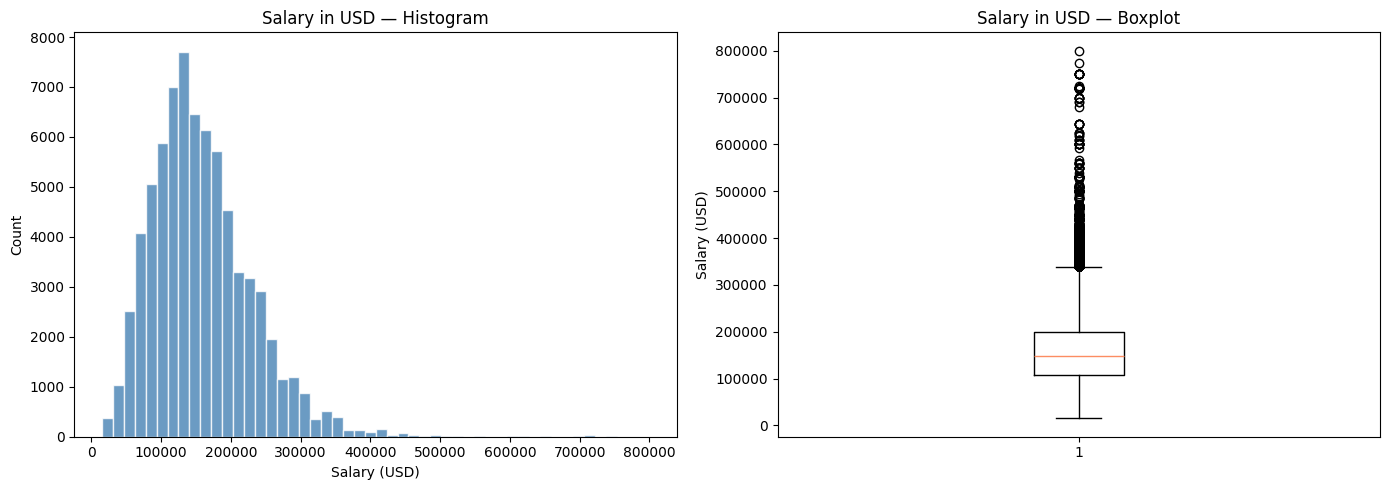

Mean:   $   158,014
Median: $   147,500
Std:    $    72,501


In [8]:
# Salary distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['salary_in_usd'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Salary in USD — Histogram')
axes[0].set_xlabel('Salary (USD)')
axes[0].set_ylabel('Count')

# Boxplot
axes[1].boxplot(df['salary_in_usd'], vert=True)
axes[1].set_title('Salary in USD — Boxplot')
axes[1].set_ylabel('Salary (USD)')

plt.tight_layout()
plt.show()

print(f"Mean:   ${df['salary_in_usd'].mean():>10,.0f}")
print(f"Median: ${df['salary_in_usd'].median():>10,.0f}")
print(f"Std:    ${df['salary_in_usd'].std():>10,.0f}")

**Reading the output:**
- The histogram shows a right-skewed distribution — most salaries cluster in the $80k-$150k range, with a long tail extending to very high values
- When mean > median, the distribution is right-skewed (a few high values pull the mean up)
- **Std** (standard deviation) measures how spread out values are around the mean. Here $72k std against a $158k mean means salaries vary widely across the dataset.
- The boxplot shows the same: the median (center line) is well below the mean, and there are many dots above the upper whisker (outliers)

This skewness is typical of salary data and is something you will need to handle before modeling.

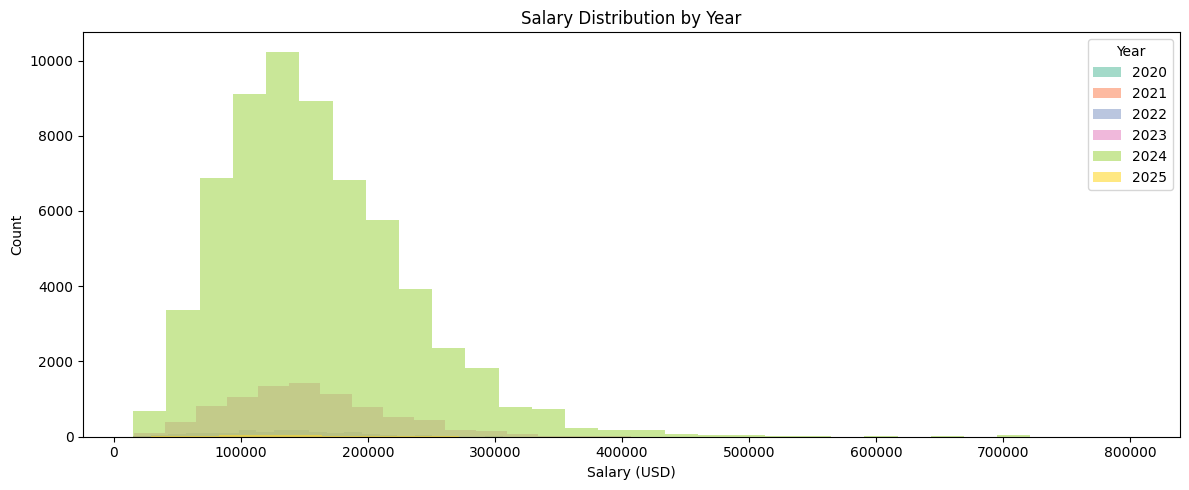

In [9]:
# Salary distribution over years
fig, ax = plt.subplots(figsize=(12, 5))

years = sorted(df['work_year'].unique())
colors = plt.cm.Set2.colors  # Set2 palette as a list of RGB tuples

for i, year in enumerate(years):  # enumerate gives (index, value) pairs
    subset = df[df['work_year'] == year]['salary_in_usd']
    ax.hist(subset, bins=30, alpha=0.6, label=str(year),
            color=colors[i % len(colors)])  # % cycles back to start if more years than colors

ax.set_title('Salary Distribution by Year')
ax.set_xlabel('Salary (USD)')
ax.set_ylabel('Count')
ax.legend(title='Year')
plt.tight_layout()
plt.show()

**TODO:** Plot a histogram for `work_year` to see how many salary records exist per year. Are all years equally represented?

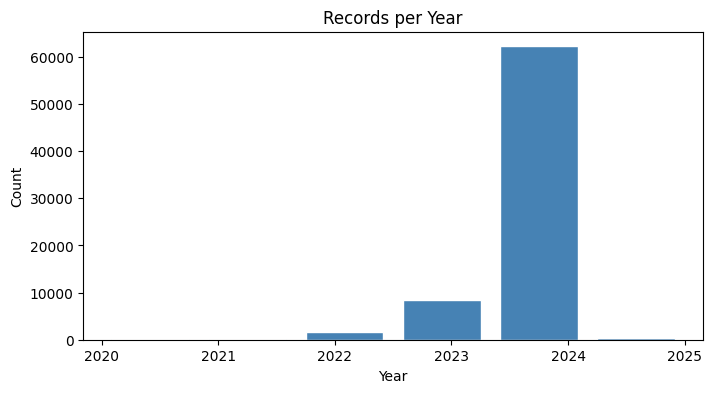

work_year
2020       75
2021      218
2022     1659
2023     8522
2024    62228
2025      446
Name: count, dtype: int64


In [10]:
# YOUR TURN
plt.figure(figsize=(8, 4))
plt.hist(df['work_year'], bins=len(df['work_year'].unique()), color='steelblue', edgecolor='white', rwidth=0.8)
plt.title('Records per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

print(df['work_year'].value_counts().sort_index())


<details><summary><b>Solution — click to expand</b></summary>

```python
plt.figure(figsize=(8, 4))
plt.hist(df['work_year'], bins=len(df['work_year'].unique()), color='steelblue', edgecolor='white', rwidth=0.8)
plt.title('Records per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

print(df['work_year'].value_counts().sort_index())
```
</details>

---
## Step 4: Categorical Distributions

For categorical columns, the key question is: what values exist, how many unique values are there, and how are they distributed?

For **ordinal** features (where order matters — EN < MI < SE < EX), always plot in logical order, not by frequency. Frequency-sorted bars hide the natural progression.

In [11]:
# Define logical orders for ordinal features (career progression, company size, remote levels)
ordinal_order = {
    'experience_level': ['EN', 'MI', 'SE', 'EX'],
    'company_size':     ['S', 'M', 'L'],
    'remote_ratio':     [0, 50, 100],
}

categorical_cols = ['experience_level', 'employment_type', 'company_size', 'remote_ratio']

for col in categorical_cols:
    if col in ordinal_order:
        counts = df[col].value_counts().reindex(ordinal_order[col])
        print(f"--- {col} (ordinal order) ---")
    else:
        counts = df[col].value_counts()  # frequency order is fine for nominal
        print(f"--- {col} ---")
    print(counts)
    print()

--- experience_level (ordinal order) ---
experience_level
EN     6877
MI    21851
SE    42926
EX     1494
Name: count, dtype: int64

--- employment_type ---
employment_type
FT    72808
PT      175
CT      149
FL       16
Name: count, dtype: int64

--- company_size (ordinal order) ---
company_size
S      205
M    70536
L     2407
Name: count, dtype: int64

--- remote_ratio (ordinal order) ---
remote_ratio
0      57220
50       281
100    15647
Name: count, dtype: int64



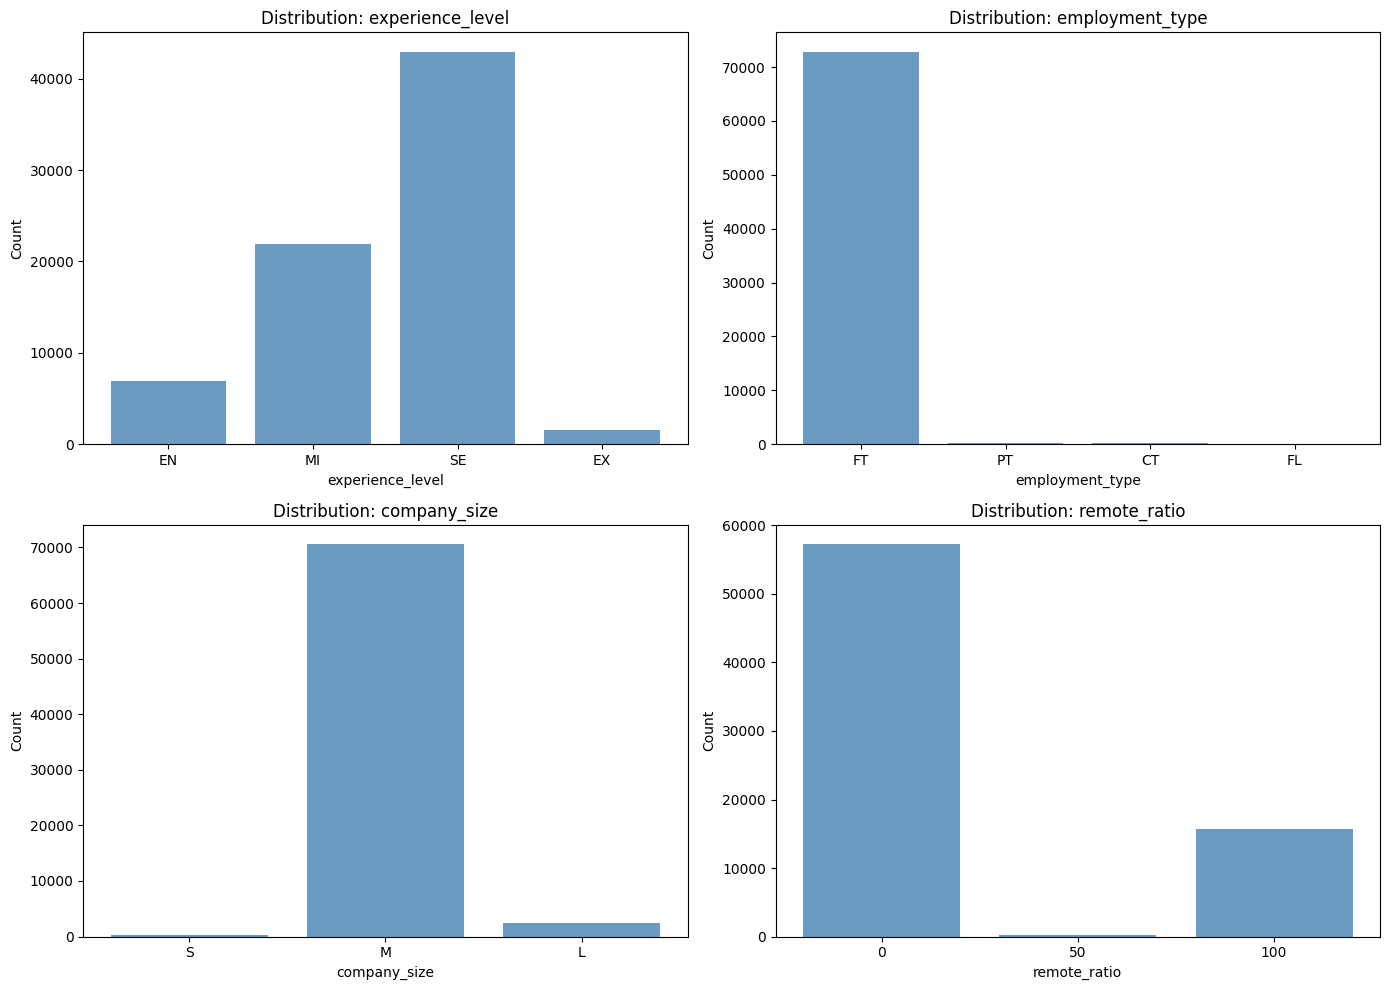

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    if col in ordinal_order:
        counts = df[col].value_counts().reindex(ordinal_order[col])
    else:
        counts = df[col].value_counts()

    axes[i].bar(counts.index.astype(str), counts.values, color='steelblue', alpha=0.8)
    axes[i].set_title(f'Distribution: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [13]:
# value_counts with normalize=True gives proportions instead of counts
print("experience_level proportions:")
print(df['experience_level'].value_counts(normalize=True).reindex(ordinal_order['experience_level']).round(3))

experience_level proportions:
experience_level
EN    0.094
MI    0.299
SE    0.587
EX    0.020
Name: proportion, dtype: float64


**Observations from the categorical plots:**
- `experience_level`: Senior (SE) and mid-level (MI) dominate. Entry-level (EN) is underrepresented (~9%). Expect models trained on this data to perform less reliably for junior roles.
- `employment_type`: Nearly all records are full-time (FT). This column carries almost no signal for a model — a feature with 95%+ the same value rarely helps prediction.
- `company_size`: Medium companies are by far the largest group.
- `remote_ratio`: On-site (0) is most common. The dataset skews recent years when remote work declined post-pandemic.

This kind of observation — noting imbalances and near-constant columns — directly shapes your feature engineering decisions.

In [14]:
# High-cardinality columns (many unique values)
print("Unique values per column:")
for col in df.columns:
    n = df[col].nunique()
    print(f"  {col}: {n}")

Unique values per column:
  work_year: 6
  experience_level: 4
  employment_type: 4
  job_title: 289
  salary: 7094
  salary_currency: 25
  salary_in_usd: 7702
  employee_residence: 93
  remote_ratio: 3
  company_location: 86
  company_size: 3


> **High cardinality warning:** Columns like `job_title` have many unique values (100+). These need special handling before modeling — you cannot one-hot encode 100+ job titles without creating a very wide, sparse feature matrix. Options include grouping rare categories, using target encoding, or dropping the column.

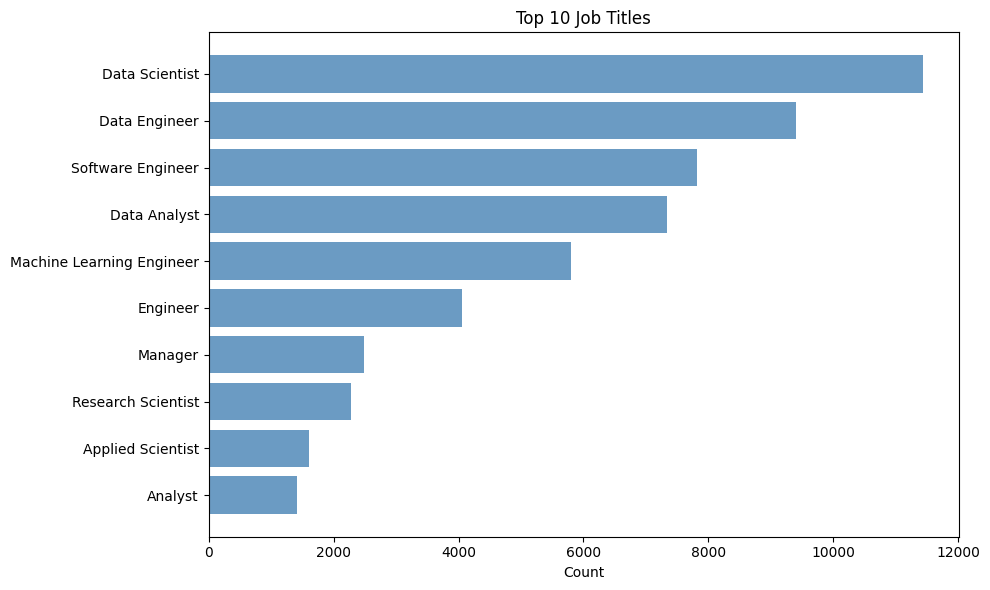

In [15]:
# Top 10 job titles
plt.figure(figsize=(10, 6))
top_titles = df['job_title'].value_counts().head(10)
plt.barh(top_titles.index, top_titles.values, color='steelblue', alpha=0.8)
plt.title('Top 10 Job Titles')
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**TODO:** Calculate the percentage of records for each `company_size` category. Which size is most represented? Print the counts and percentages.

In [17]:
# YOUR TURN
counts = df['company_size'].value_counts()
percentages = (counts / len(df) * 100).round(1)

result = pd.DataFrame({'count': counts, 'percentage': percentages})
result.index.name = 'company_size'
print(result)


              count  percentage
company_size                   
M             70536        96.4
L              2407         3.3
S               205         0.3


<details><summary><b>Solution — click to expand</b></summary>

```python
counts = df['company_size'].value_counts()
percentages = (counts / len(df) * 100).round(1)

result = pd.DataFrame({'count': counts, 'percentage': percentages})
result.index.name = 'company_size'
print(result)
```
</details>

---
## Summary

You have completed the first four items of the EDA checklist:

1. **Shape** — you know how many rows and columns the dataset has
2. **Dtypes** — you identified that `remote_ratio` is numeric but effectively categorical
3. **Missing values** — you know where data is missing and at what rate
4. **Distributions** — you saw that `salary_in_usd` is right-skewed, `employment_type` is heavily imbalanced, and `job_title` has high cardinality